## Data Exploration

Load required libraries

In [59]:


import numpy as np # For numerical computation
import pandas as pd # Data manipulation
import seaborn as sns # plotting
import h5py
import neurokit2 as nk

from matplotlib import pyplot as plt

# Plot colors used across the notebook: SBP in blue, DBP in orange
SBP_COLOR = '#2a78d6'
DBP_COLOR = '#eb6834'

Inspect folder structure

In [60]:
import os
os.listdir('../data/cuff_less_bp_estimation')


['Part_1.mat', 'Part_2.mat', 'Part_3.mat', 'Part_4.mat', '__MACOSX']

Load in matlab files. We use the h5py library:

In [61]:
sample_filepath = f'../data/cuff_less_bp_estimation/Part_{1}.mat'
sample_file = h5py.File(sample_filepath)
print(f'sample_file Data type: {type(sample_file)}')
print(f'sample_file keys:\n{sample_file.keys()}')


sample_file Data type: <class 'h5py._hl.files.File'>
sample_file keys:
<KeysViewHDF5 ['#refs#', 'Part_1']>


Let us focus on the Part_1 dataset for now. 

We start by examining the shape. Note that h5py assumes row-major order while native Matlab file assumes column-major order. The dataset has the shape (num_recordings, 1)

In [62]:
data_native = sample_file['Part_1']

print(type(data_native))
print(data_native.shape)       # data represented as np_array (3000 rows x 1 col)

n_samples = data_native.shape[0]
print(f"Total Samples: {n_samples}") # data is stored as references to h5py.Reference objects


<class 'h5py._hl.dataset.Dataset'>
(3000, 1)
Total Samples: 3000


Let us look more closely at individual references in the dataset. It is important to note that the entries in the array are *references* to the real data. We start by inspecting the first reference.

When we call data_native[i, 0] we get the reference for recording i.

We know that the sampling rate is 125Hz, or 125 measurements every second.
We divide the length of each reading by 125 to get the number of seconds in each reading




In [63]:
sample_ref = sample_file[data_native[0, 0]] # derefence first sample
temp_mat = np.array(sample_ref).T # convert to transposed numpy array for easier operations

print(f"Number of readings in each sample: {temp_mat.shape[0]}")   # readings
print(f"Number of samples in each reading (ECG): {temp_mat.shape[1]}")  # length

print (f"\nShape is {temp_mat.shape} where 3 is the number of readings (ECG, PPG, ABP) and {temp_mat.shape[1]} is the length of each.\n"
)
temp_length = temp_mat.shape[1]
sample_size = 125

print(f"The length of each reading is: {temp_length}")
print(f"The number of seconds in each reading is: {temp_length // sample_size}")


Number of readings in each sample: 3
Number of samples in each reading (ECG): 61000

Shape is (3, 61000) where 3 is the number of readings (ECG, PPG, ABP) and 61000 is the length of each.

The length of each reading is: 61000
The number of seconds in each reading is: 488


Let us examine another sample:

In [64]:
sample_ref = data_native[999, 0] # derefence first sample
temp_mat = np.array(sample_file[sample_ref]).T # convert to transposed numpy array for easier operations

print(f"Number of readings in each sample: {temp_mat.shape[0]}")   # readings
print(f"Number of samples in each reading (ECG): {temp_mat.shape[1]}")  # length

print (f"\nShape is {temp_mat.shape} where 3 is the number of readings (ECG, PPG, ABP) and {temp_mat.shape[1]} is the length of each.\n"
)
temp_length = temp_mat.shape[1]
sample_size = 125
print(f"The length of each reading is: {temp_length}")
print(f"The number of seconds in each reading is: {temp_length // sample_size}")


Number of readings in each sample: 3
Number of samples in each reading (ECG): 9000

Shape is (3, 9000) where 3 is the number of readings (ECG, PPG, ABP) and 9000 is the length of each.

The length of each reading is: 9000
The number of seconds in each reading is: 72


We explore the recording length by dividing each measurement by the frequency. This allows us to see if there are any imbalances in our dataset, and see how many 5-second windows we can extract.

In [65]:
lengths = []
for i in range(data_native.shape[0]):        # loop over all recordings
    sample_ref = data_native[i, 0]           # get the reference for recording i
    temp_mat = np.array(sample_file[sample_ref]).T  # dereference + convert to np array + transpose
    lengths.append(temp_mat.shape[1])

lengths = np.array(lengths)


print(f"Total recordings: {len(lengths)}")
print(f"Min length: {lengths.min()} samples ({lengths.min()/sample_size:.1f} sec)")
print(f"Max length: {lengths.max()} samples ({lengths.max()/sample_size:.1f} sec)")
print(f"Mean length: {lengths.mean():.0f} samples ({lengths.mean()/sample_size:.1f} sec)")
print(f"Median length: {np.median(lengths):.0f} samples")

Total recordings: 3000
Min length: 1000 samples (8.0 sec)
Max length: 74000 samples (592.0 sec)
Mean length: 27591 samples (220.7 sec)
Median length: 19000 samples


We graph the differing lengths to see the distribution of durations:

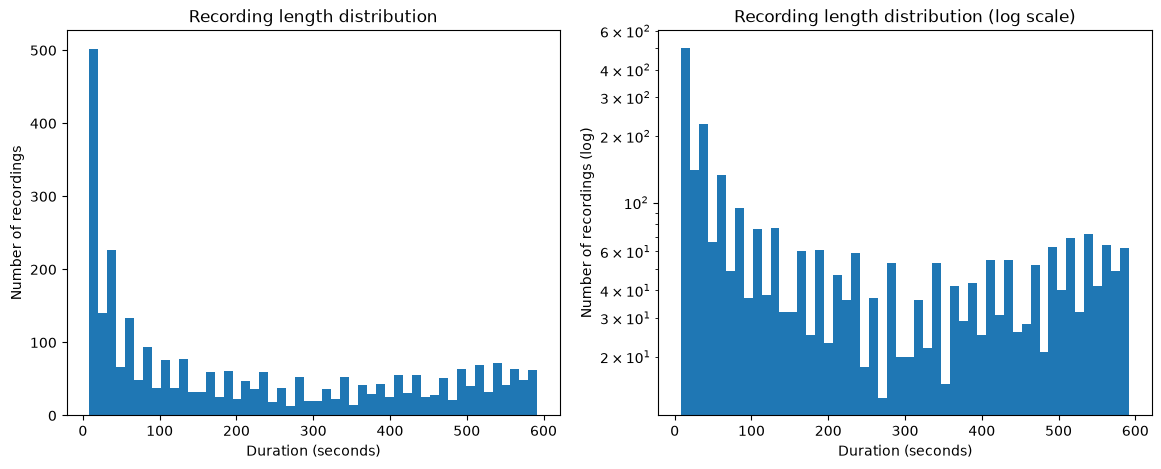

In [66]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(lengths / sample_size, bins=50)
ax[0].set_title('Recording length distribution')
ax[0].set_xlabel('Duration (seconds)')
ax[0].set_ylabel('Number of recordings')

ax[1].hist(lengths / sample_size, bins=50)
ax[1].set_yscale('log')
ax[1].set_title('Recording length distribution (log scale)')
ax[1].set_xlabel('Duration (seconds)')
ax[1].set_ylabel('Number of recordings (log)')

plt.show()

### Checking one full recording

Before windowing, we load one full recording (Part 1, index 0) and check it for missing or infinite values.

In [67]:
# Load one full recording (Part 1, index 0) for the recording-level checks below 
from scipy.signal import find_peaks
from IPython.display import display

RECORD_ID = 0
record = np.array(sample_file[data_native[RECORD_ID, 0]]).T   # shape (3, n_samples): PPG, ABP, ECG
rec_ppg, rec_abp, rec_ecg = record
signals = pd.DataFrame({"PPG": rec_ppg, "ABP": rec_abp, "ECG": rec_ecg})
print(f"Part 1, recording index {RECORD_ID}")
print(f"{len(rec_ppg):,} samples per channel; {len(rec_ppg)/sample_size:.1f} seconds")

Part 1, recording index 0
61,000 samples per channel; 488.0 seconds


Signal checks (this recording only):


,missing_nan,infinite,zeros
PPG,0,0,15
ABP,0,0,0
ECG,0,0,0


Signal summary (ABP is in mmHg; PPG/ECG use stored units):


,PPG,ABP,ECG
count,61000.000,61000.000,61000.000
mean,1.840,94.658,0.226
std,0.632,20.567,0.255
min,0.000,50.163,-0.240
25%,1.310,78.541,0.090
50%,1.624,86.259,0.185
75%,2.422,112.928,0.305
max,4.002,160.111,1.501


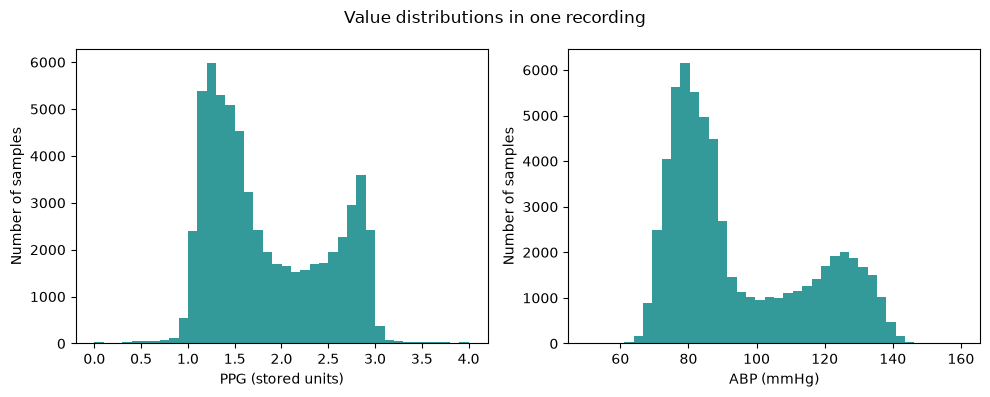

In [68]:
# Basic EDA: check missing readings and describe the stored values 
# A zero is counted separately. It is not automatically a missing value.
checks = pd.DataFrame({
    "missing_nan": signals.isna().sum(),
    "infinite": np.isinf(signals).sum(),
    "zeros": signals.eq(0).sum(),
})
print("Signal checks (this recording only):")
display(checks)
print("Signal summary (ABP is in mmHg; PPG/ECG use stored units):")
display(signals.describe().round(3))
if not np.isfinite(record[:2]).all():
    raise ValueError("PPG or ABP contains nonfinite values. Review before processing.")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, values, label in zip(axes, [rec_ppg, rec_abp], ["PPG (stored units)", "ABP (mmHg)"]):
    ax.hist(values, bins=40, color="teal", alpha=0.8)
    ax.set(xlabel=label, ylabel="Number of samples")
fig.suptitle("Value distributions in one recording")
fig.tight_layout()
plt.show()

In our, project spec, we are advised to to process each signal into 5-second windows. Each window should therefore contain 625 PPG samples as input and a pair of blood pressure values as labels. 

To inspect the entire dataset, we iterate through each recording and extract 5-second windows.



In [69]:
window_size = 625  # 5 seconds of data at 125Hz
ppg, ecg, bp = [], [], []
sbp, dbp = [], []  # Systolic / Diastolic Blood Pressure labels

for i in range(data_native.shape[0]):          # loop over all recordings (row axis)
    sample_ref = data_native[i, 0]              # get reference for recording i
    temp_mat = np.array(sample_file[sample_ref]).T  # dereference + materialize + transpose 
    temp_length = temp_mat.shape[1]

    n_windows = temp_length // window_size
    for j in range(n_windows):
        start, end = j * window_size, (j + 1) * window_size

        temp_ppg = temp_mat[0, start:end]  # PPG window
        temp_bp  = temp_mat[1, start:end]  # ABP window
        temp_ecg = temp_mat[2, start:end]  # ECG window

        sbp.append(temp_bp.max())   # peak ABP ≈ systolic
        dbp.append(temp_bp.min())   # trough ABP ≈ diastolic

        ppg.append(temp_ppg)
        ecg.append(temp_ecg)
        bp.append(temp_bp)

ppg = np.array(ppg)
ecg = np.array(ecg)
bp  = np.array(bp)
sbp = np.array(sbp)
dbp = np.array(dbp)

print(f"Total windows extracted: {len(ppg)}")
print(f"PPG shape: {ppg.shape}")   # (n_windows, 625)
print(f"SBP range: {sbp.min():.1f} - {sbp.max():.1f}")
print(f"DBP range: {dbp.min():.1f} - {dbp.max():.1f}")

Total windows extracted: 131163
PPG shape: (131163, 625)
SBP range: 67.2 - 199.9
DBP range: 50.0 - 184.5


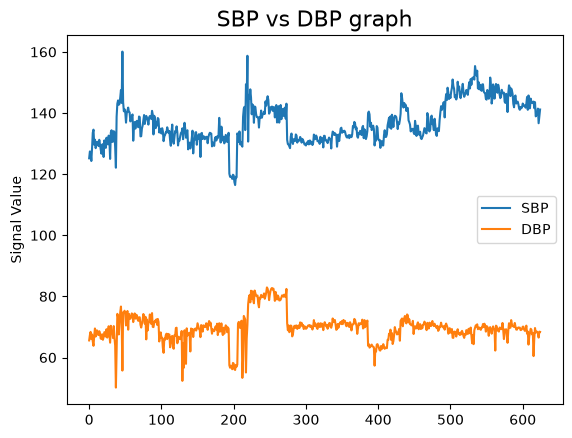

In [70]:
## Visualizing SBP and DBP
#fig, ax = plt.subplots(1,1, figsize=(9,12))

plt.title('SBP vs DBP graph', fontsize=16)
plt.ylabel('Signal Value')
plt.plot(sbp[:625])
plt.plot(dbp[:625])
plt.legend(['SBP', 'DBP'])

We plot the ranges to check for outliers
(from NIH: https://www.ncbi.nlm.nih.gov/books/NBK570233/table/ch1.tab1/)


| JNC 7 Classification | SBP (mm Hg) | DBP (mm Hg) | ACC/AHA Category | SBP (mm Hg) | DBP (mm Hg) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Normal | <120 | <80 | Normal | <120 | <80 |
| Prehypertension | 120–139 | 80–89 | Elevated | 120–129 | <80 |
| Stage 1 hypertension | 140–159 | 90–99 | Stage 1 hypertension | 130–139 | 80–89 |
| Stage 2 hypertension* | ≥160 | ≥100 | Stage 2 hypertension | ≥140 | ≥90 |


Outside possible range: 67 / 131163 (0.1%)


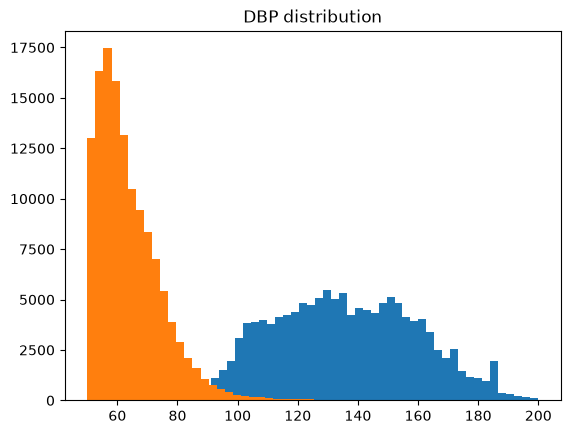

In [71]:
plt.hist(sbp, bins=50); plt.title('SBP distribution')
plt.hist(dbp, bins=50); plt.title('DBP distribution')

pulse_pressure = sbp - dbp
implausible = (sbp < 60) | (sbp > 220) | (dbp < 30) | (dbp > 130) | (pulse_pressure < 10)
print(f"Outside possible range: {implausible.sum()} / {len(sbp)} ({implausible.mean()*100:.1f}%)")

### Comparing recordings

Do the other recordings look similar to recording 0? These are recording segments, not five confirmed different people.

First five recordings (mean ABP is not SBP or DBP):


,record_id,duration_seconds,complete_windows,windows_without_rate,median_window_pulse_rate_bpm,ppg_mean,ppg_std,mean_abp_mmHg
0,0,488.0,97,0,122.95,1.84,0.63,94.66
1,1,488.0,97,0,119.05,1.83,0.63,91.75
2,2,400.0,80,0,115.38,1.83,0.63,98.13
3,3,560.0,112,0,117.19,1.83,0.61,93.37
4,4,552.0,110,0,108.70,1.77,0.63,92.79


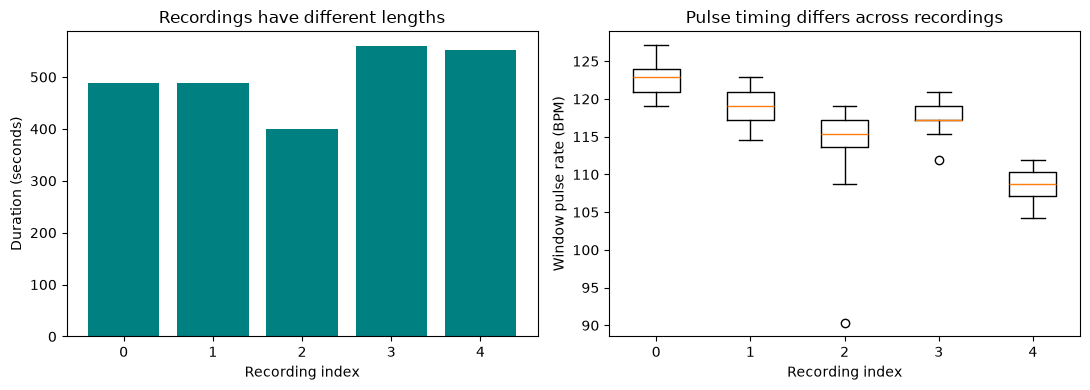

In [72]:
# Compare the first five recordings instead of relying on one example 
# These are recording segments, not five confirmed different people.
comparison_rows = []
rate_groups = []
for rid in range(min(5, data_native.shape[0])):
    x = np.array(sample_file[data_native[rid, 0]]).T
    if not np.isfinite(x[:2]).all():
        raise ValueError(f"Review nonfinite readings in recording {rid}.")
    filtered = nk.ppg_clean(x[0], sampling_rate=sample_size, method="elgendi")
    _, detected = nk.ppg_peaks(filtered, sampling_rate=sample_size, method="elgendi")
    pk = np.asarray(detected["PPG_Peaks"], dtype=int)
    rates = []
    for wid in range(x.shape[1] // window_size):
        in_window = pk[(pk >= wid * window_size) & (pk < (wid + 1) * window_size)]
        gaps = np.diff(in_window) / sample_size
        rates.append(60 / np.median(gaps) if len(gaps) else np.nan)
    rates = np.asarray(rates)
    finite_rates = rates[np.isfinite(rates)]
    rate_groups.append(finite_rates)
    comparison_rows.append({
        "record_id": rid,
        "duration_seconds": x.shape[1] / sample_size,
        "complete_windows": len(rates),
        "windows_without_rate": int(np.isnan(rates).sum()),
        "median_window_pulse_rate_bpm": float(np.median(finite_rates)) if len(finite_rates) else np.nan,
        "ppg_mean": float(x[0].mean()),
        "ppg_std": float(x[0].std()),
        "mean_abp_mmHg": float(x[1].mean()),
    })
comparison = pd.DataFrame(comparison_rows)
print("First five recordings (mean ABP is not SBP or DBP):")
display(comparison.round(2))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(comparison.record_id.astype(str), comparison.duration_seconds, color="teal")
axes[0].set(xlabel="Recording index", ylabel="Duration (seconds)", title="Recordings have different lengths")
axes[1].boxplot(rate_groups, tick_labels=comparison.record_id.astype(str).tolist())
axes[1].set(xlabel="Recording index", ylabel="Window pulse rate (BPM)", title="Pulse timing differs across recordings")
fig.tight_layout()
plt.show()

### Does the ABP peak detector setting change the labels?

SBP/DBP here come from automatic peak detection. We check whether the detector's prominence setting changes the labels for recording 0. Agreement across settings is reassuring, but does not prove correctness.

In [73]:
# Check whether the ABP detector setting changes the draft targets 
# Prominence measures how much a peak stands above nearby low points.
# Agreement across settings is reassuring, but does not prove correctness.
sensitivity_rows = []
for prominence in [5, 10, 15]:
    bp_peaks, _ = find_peaks(rec_abp, distance=round(.30 * sample_size), prominence=prominence)
    lows_idx = np.array([a + np.argmin(rec_abp[a:b+1]) for a, b in zip(bp_peaks[:-1], bp_peaks[1:])], dtype=int)
    for wid in range(len(rec_abp) // window_size):
        valid = (bp_peaks[:-1] >= wid * window_size) & (bp_peaks[1:] < (wid + 1) * window_size)
        sensitivity_rows.append({
            "window_id": wid, "prominence_mmHg": prominence,
            "complete_intervals": int(valid.sum()),
            "draft_sbp_mmHg": float(np.median(rec_abp[bp_peaks[:-1][valid]])) if valid.any() else np.nan,
            "draft_dbp_mmHg": float(np.median(rec_abp[lows_idx[valid]])) if valid.any() else np.nan,
        })
sensitivity = pd.DataFrame(sensitivity_rows)

print("Target differences across three detector settings (recording 0 only):")
for target in ["draft_sbp_mmHg", "draft_dbp_mmHg"]:
    table = sensitivity.pivot(index="window_id", columns="prominence_mmHg", values=target)
    comparable = table.dropna()  # Compare only windows with targets at every setting.
    spread = comparable.max(axis=1) - comparable.min(axis=1)
    print(f"{target}: {len(comparable)} comparable windows; "
          f"{int((spread > 0.01).sum())} differ by more than 0.01 mmHg; "
          f"largest difference = {spread.max():.2f} mmHg")

Target differences across three detector settings (recording 0 only):
draft_sbp_mmHg: 97 comparable windows; 0 differ by more than 0.01 mmHg; largest difference = 0.00 mmHg
draft_dbp_mmHg: 97 comparable windows; 0 differ by more than 0.01 mmHg; largest difference = 0.00 mmHg


## Neurokit2 Exploration:

```ppg_process```/```ecg_process``` - runs the following functions onder the hood: 
- cleans data(```nk.ecg_clean()```/```nk.ppg_clean()```) - filters drift and noise.
- peak detection(```nk.ecg_findpeaks()```/```nk.ppg_findpeaks()```) - use cleaned signal to locate peaks
- quality scoring(```nk.nk.ecg_quality()```/```nk.ppg_quality()```) - assess signal quality
- rate estimation(```nk.signal_rate()```) - calculates heart rate estimation in BPM based on detected peak intervals
- Returns ```signals``` df and ```info``` df
- ```ecg_signals``` -> returns the following columns in df. same applies for ```ppg_signals```
    -  ```ECG_Raw``` - raw signal
    - ```ECG_Clean``` - filtered signal
    - ```ECG_R_Peaks``` - binary mask, 1 for peak, 0 otherwise
    - ```ECG_Rate``` - interpolated heart rate in BPM

We can visualize the results using Neurokit2's built-in plot functionality.


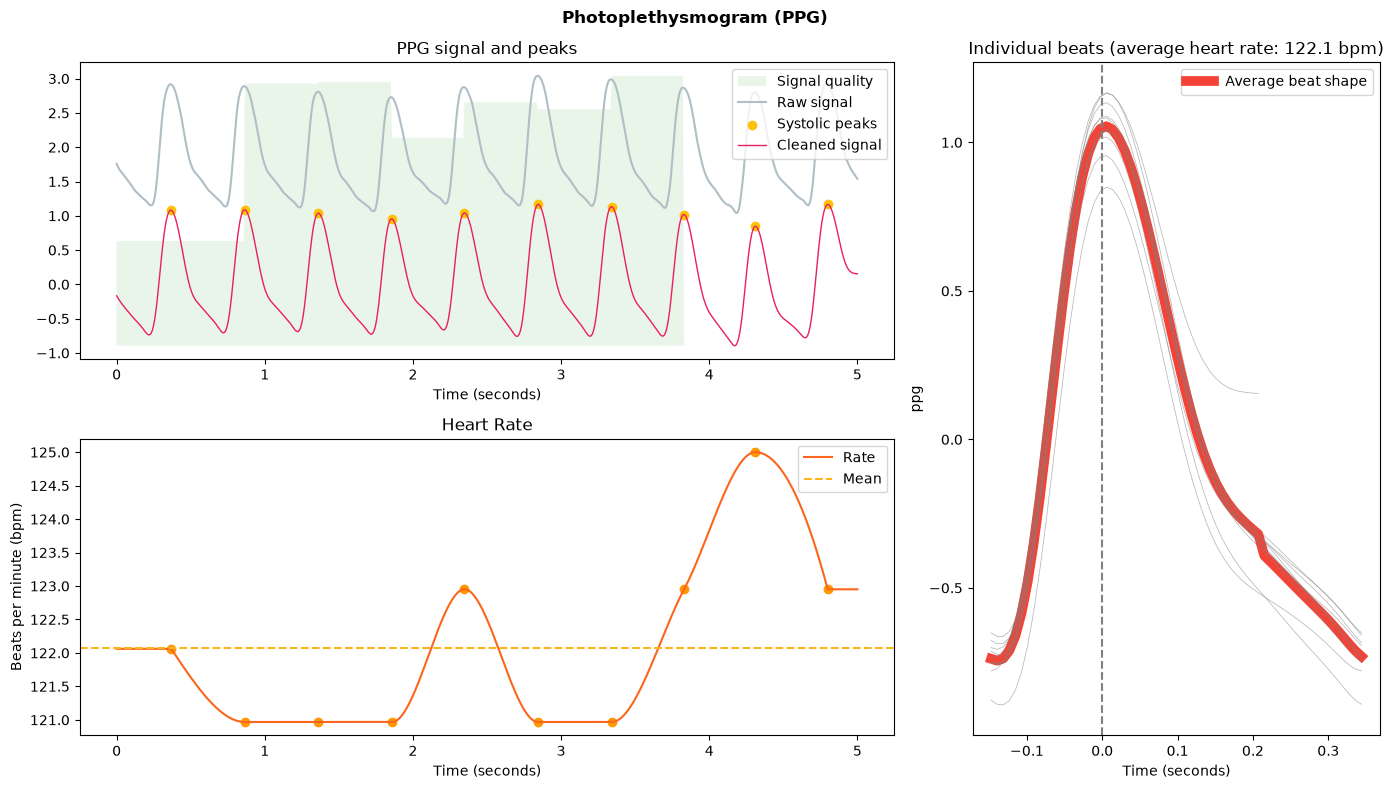

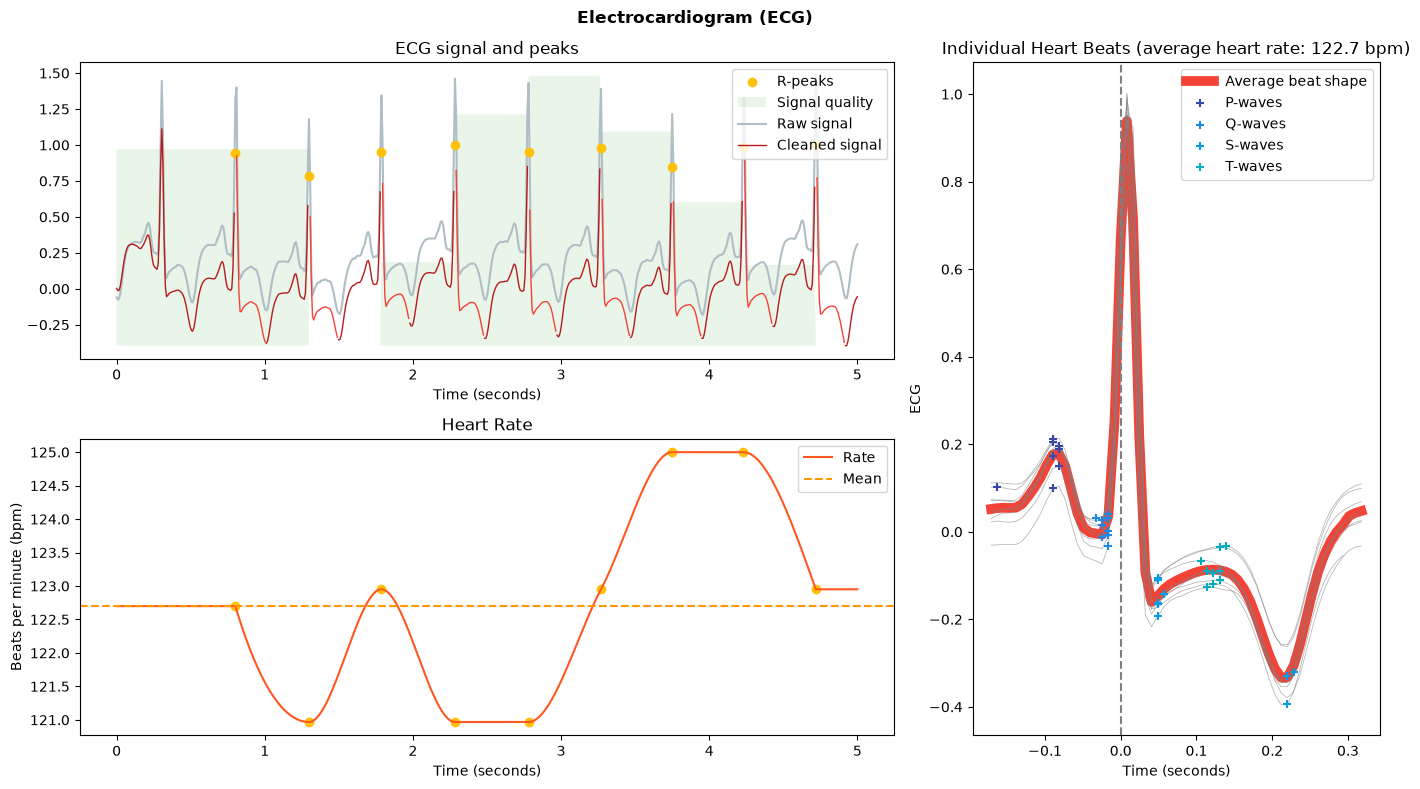

In [74]:
ppg_signals, ppg_info = nk.ppg_process(ppg[0], sampling_rate=sample_size)
ecg_signals, ecg_info = nk.ecg_process(ecg[0], sampling_rate=sample_size)

# graph results using builtin plot function
nk.ppg_plot(ppg_signals, ppg_info)
fig = plt.gcf()
fig.set_size_inches(14, 8)
plt.tight_layout()
nk.ecg_plot(ecg_signals, ecg_info)
fig = plt.gcf()
fig.set_size_inches(14, 8)
plt.tight_layout()

In [75]:
ppg_subset = ppg[:500]
ecg_subset = ecg[:500]

records = []
for i in range(len(ppg_subset)):
    try:
        ppg_sig, ppg_info = nk.ppg_process(ppg_subset[i], sampling_rate=125)
        ecg_sig, ecg_info = nk.ecg_process(ecg_subset[i], sampling_rate=125)
        records.append({
            'window': i,
            'ppg_quality': ppg_sig['PPG_Quality'].mean(),
            'ecg_quality': ecg_sig['ECG_Quality'].mean(),
            'n_ppg_peaks': len(ppg_info['PPG_Peaks']),
            'n_r_peaks': len(ecg_info['ECG_R_Peaks']),
            'failed': False,
        })
    except Exception:
        records.append({
            'window': i,
            'ppg_quality': np.nan,
            'ecg_quality': np.nan,
            'n_ppg_peaks': np.nan,
            'n_r_peaks': np.nan,
            'failed': True,
        })

quality_df = pd.DataFrame(records)

In [76]:
quality_df[quality_df["failed"] == True]


,window,ppg_quality,ecg_quality,n_ppg_peaks,n_r_peaks,failed


### Where the morphology features come from

The plot below shows a single PPG window alongside its 1st derivative (VPG) and
2nd derivative (APG), with detected systolic peaks marked.

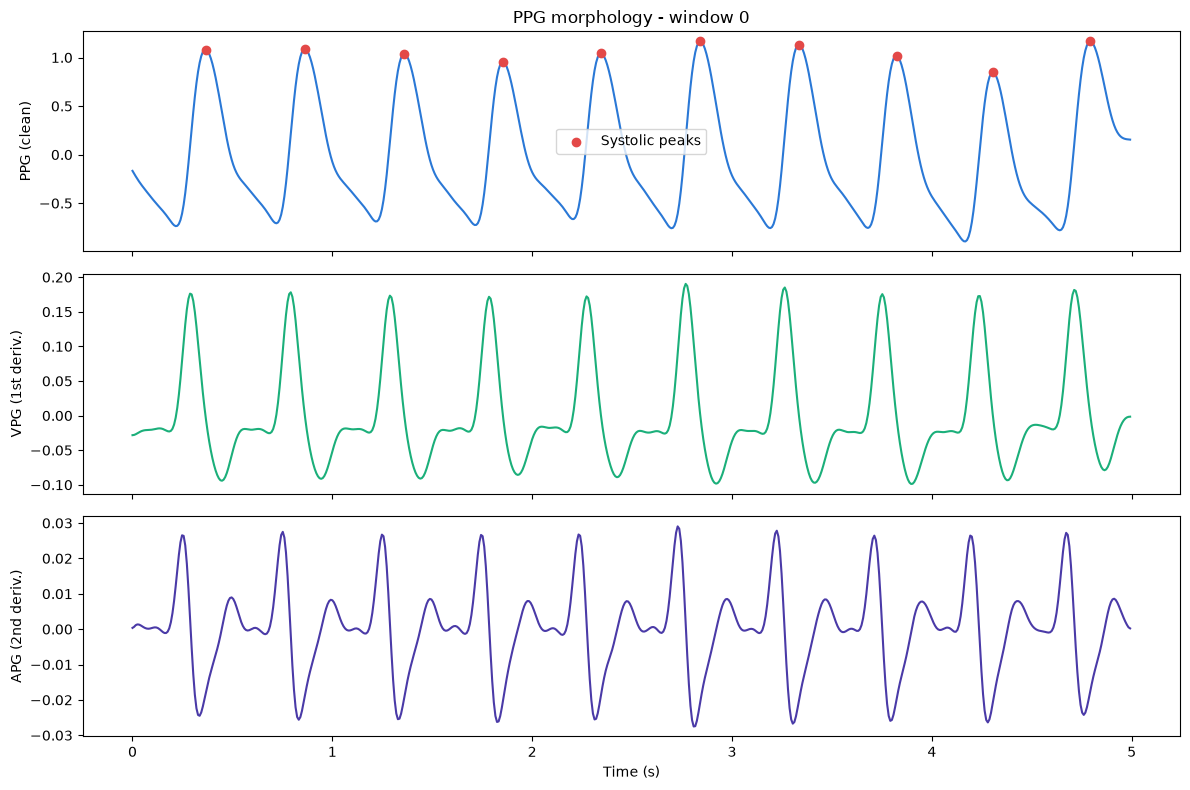

In [77]:
idx = 0
ppg_sig, ppg_info = nk.ppg_process(ppg[idx], sampling_rate=sample_size)

clean = ppg_sig['PPG_Clean'].values
peaks = ppg_info['PPG_Peaks']
vpg = np.gradient(clean)
apg = np.gradient(vpg)
t = np.arange(len(clean)) / sample_size

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(t, clean, color=SBP_COLOR)
axes[0].scatter(t[peaks], clean[peaks], color='#e34948', zorder=5, label='Systolic peaks')
axes[0].set_ylabel('PPG (clean)')
axes[0].set_title(f'PPG morphology - window {idx}')
axes[0].legend()

axes[1].plot(t, vpg, color='#1baf7a')
axes[1].set_ylabel('VPG (1st deriv.)')

axes[2].plot(t, apg, color='#4a3aa7')
axes[2].set_ylabel('APG (2nd deriv.)')
axes[2].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()


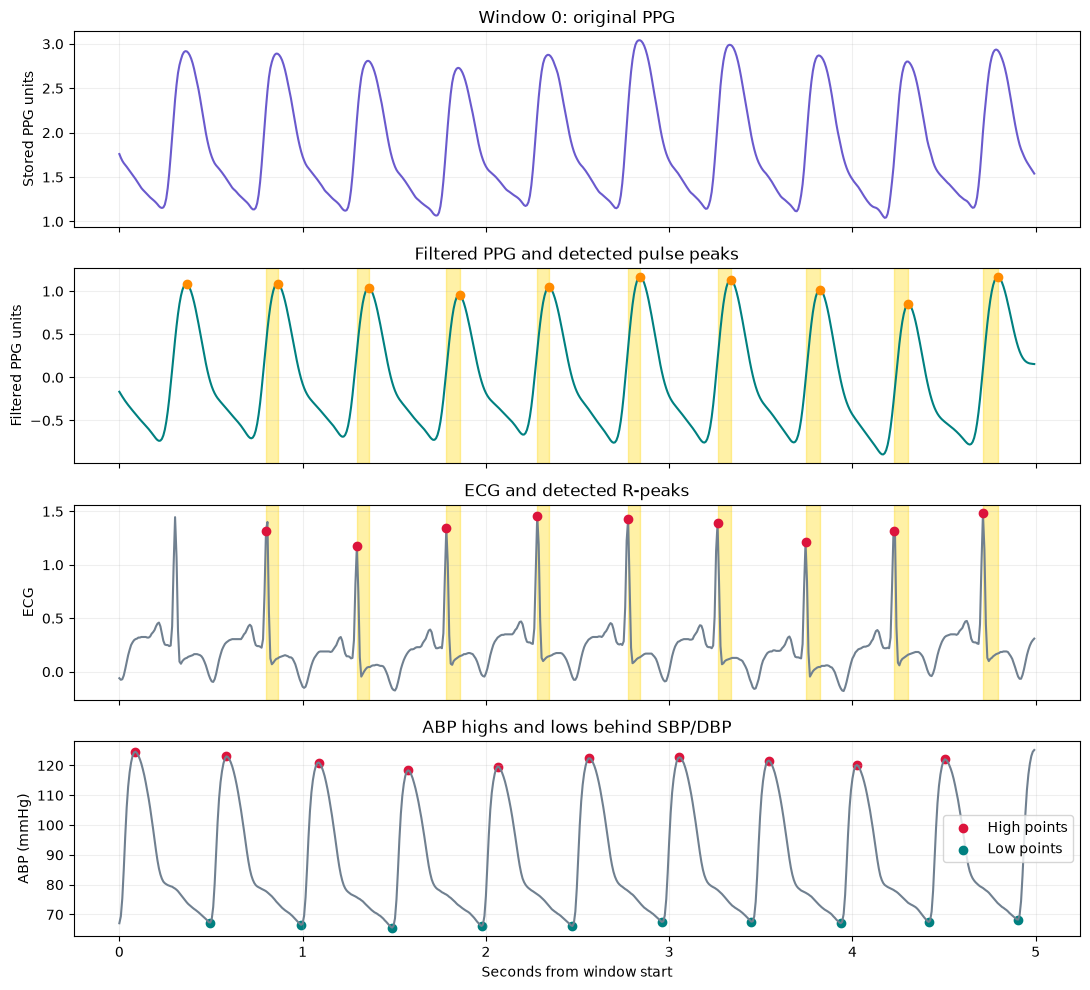

In [78]:
# Check the detected peaks against the signals for one window 
# Change idx to look at another window. Gold bands = PTT (R-peak -> next PPG peak).
idx = 0
ppg_sig, ppg_info = nk.ppg_process(ppg[idx], sampling_rate=sample_size)
ecg_sig, ecg_info = nk.ecg_process(ecg[idx], sampling_rate=sample_size)
cleaned = ppg_sig['PPG_Clean'].values
selected = np.asarray(ppg_info['PPG_Peaks'], dtype=int)
r_peaks = np.asarray(ecg_info['ECG_R_Peaks'], dtype=int)
highs, _ = find_peaks(bp[idx], distance=round(0.40 * sample_size))
lows, _ = find_peaks(-bp[idx], distance=round(0.40 * sample_size))
time = np.arange(window_size) / sample_size

fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
axes[0].plot(time, ppg[idx], color="slateblue")
axes[0].set(ylabel="Stored PPG units", title=f"Window {idx}: original PPG")
axes[1].plot(time, cleaned, color="teal")
axes[1].scatter(selected / sample_size, cleaned[selected], color="darkorange", zorder=3)
axes[1].set(ylabel="Filtered PPG units", title="Filtered PPG and detected pulse peaks")
axes[2].plot(time, ecg[idx], color="slategray")
axes[2].scatter(r_peaks / sample_size, ecg[idx][r_peaks], color="crimson", zorder=3)
axes[2].set(ylabel="ECG", title="ECG and detected R-peaks")
axes[3].plot(time, bp[idx], color="slategray")
axes[3].scatter(highs / sample_size, bp[idx][highs], color="crimson", label="High points")
axes[3].scatter(lows / sample_size, bp[idx][lows], color="teal", label="Low points")
axes[3].set(xlabel="Seconds from window start", ylabel="ABP (mmHg)", title="ABP highs and lows behind SBP/DBP")
axes[3].legend()
for r in r_peaks:
    nxt = selected[(selected > r) & (selected < r + int(0.6 * sample_size))]
    if len(nxt):
        for ax in (axes[1], axes[2]):
            ax.axvspan(r / sample_size, nxt[0] / sample_size, color="gold", alpha=0.35)
for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## Feature Engineering for ML Model

We extract some potential features for an ML Model after processing with Neurokit2:

- **PPG pulse morphology** - systolic amplitude, pulse width, pulse area, the first derivative (VPG), and the
  second-derivative (APG) b/a ratio, a known proxy for arterial stiffness.
- **Heart rate & variability** - PPG-derived heart rate, and some summary statistics. BP and heart rate are correlated, so variability can reflect stress and health factors

We extract these using 5-second windows.

In [79]:
def extract_ppg_features(ppg_signals, ppg_info, sampling_rate=125):
    """PPG window information from output of nk.ppg_process"""
    peaks = ppg_info['PPG_Peaks'] # positions of the pulse peaks, one per heartbeat
    clean = ppg_signals['PPG_Clean'].values # PPG cleaned

    # return if less than 2 beats in a window since we cannot measure anything
    if len(peaks) < 2:
        return None

    peak_intervals = np.diff(peaks) / sampling_rate  # use np.diff to subtract neighboring peak positions to get interval between heartbeats

    # iterate through to analyze one pulse at a time
    amplitudes, widths, areas = [], [], []
    for i in range(len(peaks) - 1):
        pulse = clean[peaks[i]:peaks[i + 1]] # get 1 pulse (interval from one beat to another)
        trough = pulse.min()
        amplitudes.append(clean[peaks[i]] - trough)              # amplitude is peak-lowest point
        half_max = (clean[peaks[i]] + trough) / 2
        widths.append((pulse > half_max).sum() / sampling_rate)  # pulse width is how long a pulse stays above half its height 
        areas.append(np.trapezoid(pulse) / sampling_rate)        # pulse area

    vpg = np.gradient(clean)  # use np.gradient to get first derivative VPG -> shows how quickly blood volume changes
    apg = np.gradient(vpg)    # get second derivative APG -> shows acceleration

    # return summary stats:
    return {
        'ppg_hr_bpm': 60 / np.mean(peak_intervals), # heart rate (aka bpm)
        'ppg_interval_std': np.std(peak_intervals), # how much the spacing between beats varies
        'ppg_amplitude_mean': np.mean(amplitudes), 
        'ppg_amplitude_std': np.std(amplitudes),
        'ppg_pulse_width_mean': np.mean(widths),
        'ppg_pulse_area_mean': np.mean(areas),
        'ppg_apg_ba_ratio': apg.min() / apg.max() if apg.max() != 0 else np.nan,
    }



### Some more features: fiducial & non-fiducial 

From the research papers:

- **Fiducial landmarks** - landmarks on the PPG wave. This includes:
  - systolic peak - the tip of the wave
  - foot - when the wave begins to rise
  - dicrotic notch/diastolic peak - small dip in wave followed by smaller peak

- **Non-fiducial window statistics** - categorize the entire waveform. This includes:
  - distribution shape (mean/median/std/IQR/skew/kurtosis)
  - Shannon entropy (`nk.entropy_shannon`) - how unpredictable the signal is
  - Teager-Kaiser energy variance - how much the energy fluctuates
  - zero-crossing rate (`nk.signal_zerocrossings`) - how often the signal crosses 0
  computed over the PPG, VPG, and APG waveforms.


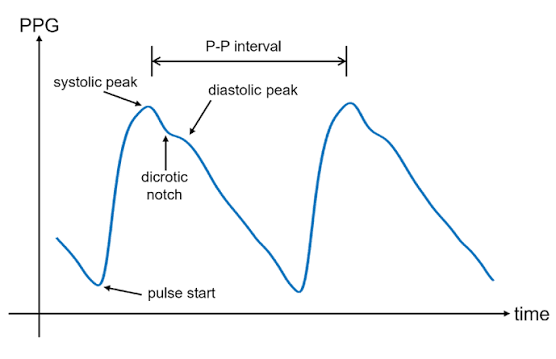

In [80]:
def extract_ppg_fiducial_features(ppg_signals, ppg_info, sampling_rate=125):
    """ 
    A healthy pulse has a clear structure (a systolic peak, followed by a dicrotic notch and diastolic peak). 
    Variances in spacing and height can reflect abnormalities.
    """
    
    # info from Neurokit2 processing
    clean = ppg_signals['PPG_Clean'].values
    peaks = ppg_info['PPG_Peaks']
    vpg = np.gradient(clean)

    if len(peaks) < 3:
        return None

    dia_sys_ratios, notch_sys_ratios = [], []
    t_foot_sys, t_foot_notch, t_foot_dia, t_sys_dia = [], [], [], []

    # iterate over each pulse to find ratios and fiducial features
    for i in range(1, len(peaks) - 1):
        foot = peaks[i - 1] + np.argmin(clean[peaks[i - 1]:peaks[i] + 1]) # find the lowest point, pulse starts at foot
        next_foot = peaks[i] + np.argmin(clean[peaks[i]:peaks[i + 1] + 1])

        vseg = vpg[peaks[i]:next_foot + 1] # go from peak to next foot to find dicrotic notch/diastolic peak
        up = nk.signal_zerocrossings(vseg, direction='up') # slope that goes from negative to positive indicates local minimum
        if len(up) == 0:
            continue
        notch_rel = up[0] 

        down = nk.signal_zerocrossings(vseg[notch_rel:], direction='down') # diastolic peak is local max
        if len(down) == 0: 
            continue
        dia_rel = notch_rel + down[0] 

        notch_idx = peaks[i] + notch_rel
        dia_idx = peaks[i] + dia_rel

        baseline = clean[foot] # foot is baseline to calculate amplitude
        sys_amp = clean[peaks[i]] - baseline
        if sys_amp <= 0:
            continue
        
        # record stats:
        dia_sys_ratios.append((clean[dia_idx] - baseline) / sys_amp) # diastolic peak height / systolic height
        notch_sys_ratios.append((clean[notch_idx] - baseline) / sys_amp) # notch ratios
        # record timings 
        t_foot_sys.append((peaks[i] - foot) / sampling_rate)
        t_foot_notch.append((notch_idx - foot) / sampling_rate)
        t_foot_dia.append((dia_idx - foot) / sampling_rate)
        t_sys_dia.append((dia_idx - peaks[i]) / sampling_rate)

    if len(dia_sys_ratios) == 0:
        return None

    return {
        'ppg_dia_sys_ratio': np.mean(dia_sys_ratios),
        'ppg_notch_sys_ratio': np.mean(notch_sys_ratios),
        't_foot_to_sys': np.mean(t_foot_sys),
        't_foot_to_notch': np.mean(t_foot_notch),
        't_foot_to_dia': np.mean(t_foot_dia),
        't_sys_to_dia': np.mean(t_sys_dia),
        'n_pulses_with_notch': len(dia_sys_ratios),  # coverage: how many pulses this window's average is based on
    }


In [81]:
from scipy import stats as sstats


def extract_window_statistics(signal, sampling_rate=125, prefix=''):
    """non-fiducial statistics (PPG, VPG, or APG)."""
    signal = np.asarray(signal, dtype=float) # convert to float array to perform calculations
    centered = signal - np.mean(signal)  # to count zero-crossings, must normalize

    shannon_entropy, _ = nk.entropy_shannon(signal, symbolize=10) # use neurokit2 to get shannon netropy

    tkeo = signal[1:-1] ** 2 - signal[:-2] * signal[2:]  # Teager-Kaiser energy 
    crossings = nk.signal_zerocrossings(centered)
    zcr = len(crossings) / (len(signal) / sampling_rate)  # crossings per second

    return {
        f'{prefix}mean': np.mean(signal),
        f'{prefix}median': np.median(signal),
        f'{prefix}std': np.std(signal),
        f'{prefix}var': np.var(signal),
        f'{prefix}iqr': sstats.iqr(signal),
        f'{prefix}skew': sstats.skew(signal),
        f'{prefix}kurtosis': sstats.kurtosis(signal),
        f'{prefix}shannon_entropy': shannon_entropy,
        f'{prefix}tkeo_var': np.var(tkeo),
        f'{prefix}zcr': zcr,
    }


In [82]:
n_feature_windows = 500  # take a subset 

feature_records = []
for i in range(n_feature_windows):
    try:
        ppg_sig, ppg_info = nk.ppg_process(ppg[i], sampling_rate=sample_size)

        ppg_feats = extract_ppg_features(ppg_sig, ppg_info, sample_size)

        if ppg_feats is None:
            continue  # skip windows with too few detected peaks to feature-ize

        record = {'window': i, 'sbp': sbp[i], 'dbp': dbp[i]}
        record.update(ppg_feats)

        # fiducial landmarks - often None on this dataset (see caveat above), so merge only if found
        fiducial_feats = extract_ppg_fiducial_features(ppg_sig, ppg_info, sample_size)
        if fiducial_feats is not None:
            record.update(fiducial_feats)

        # non-fiducial window statistics over PPG, VPG, and APG
        clean = ppg_sig['PPG_Clean'].values
        vpg = np.gradient(clean)
        apg = np.gradient(vpg)
        record.update(extract_window_statistics(clean, sample_size, prefix='ppg_stat_'))
        record.update(extract_window_statistics(vpg, sample_size, prefix='vpg_stat_'))
        record.update(extract_window_statistics(apg, sample_size, prefix='apg_stat_'))

        feature_records.append(record)
    except Exception:
        continue

features_df = pd.DataFrame(feature_records).set_index('window')
print(f"Extracted features for {len(features_df)}/{n_feature_windows} windows")
print(f"Windows with a resolvable dicrotic notch: {features_df['n_pulses_with_notch'].notna().sum()}")
features_df.head()


Extracted features for 500/500 windows
Windows with a resolvable dicrotic notch: 79


,sbp,dbp,ppg_hr_bpm,ppg_interval_std,ppg_amplitude_mean,ppg_amplitude_std,ppg_pulse_width_mean,ppg_pulse_area_mean,ppg_apg_ba_ratio,ppg_stat_mean,...,apg_stat_shannon_entropy,apg_stat_tkeo_var,apg_stat_zcr,ppg_dia_sys_ratio,ppg_notch_sys_ratio,t_foot_to_sys,t_foot_to_notch,t_foot_to_dia,t_sys_to_dia,n_pulses_with_notch
window,,,,,,,,,,,,,,,,,,,,,
0,125.187439,65.597632,122.061483,0.005479,1.789199,0.104733,0.172444,-0.018487,-0.947285,-0.011242,...,2.928221,6.361905e-10,11.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,127.434268,67.307176,124.481328,0.003464,1.798773,0.082789,0.175000,-0.012850,-0.946810,0.000174,...,2.958087,6.073876e-10,9.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,127.190048,68.381746,123.456790,0.003464,1.808343,0.120660,0.175000,-0.004666,-0.950382,0.050298,...,2.982275,5.957941e-10,6.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,124.308245,66.037229,123.175182,0.005896,1.798631,0.130368,0.172444,-0.018154,-0.933006,-0.048826,...,2.922737,6.955781e-10,9.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,128.508838,67.551396,124.223602,0.006856,1.851906,0.075868,0.177000,-0.016192,-0.967340,-0.004778,...,2.940556,6.683887e-10,10.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Feature relationships with SBP / DBP

We look at three views of the same question - "which features are worth feeding
into the model?" - a full correlation matrix, per-feature scatter plots against
each label, and a ranked summary of correlation strength.

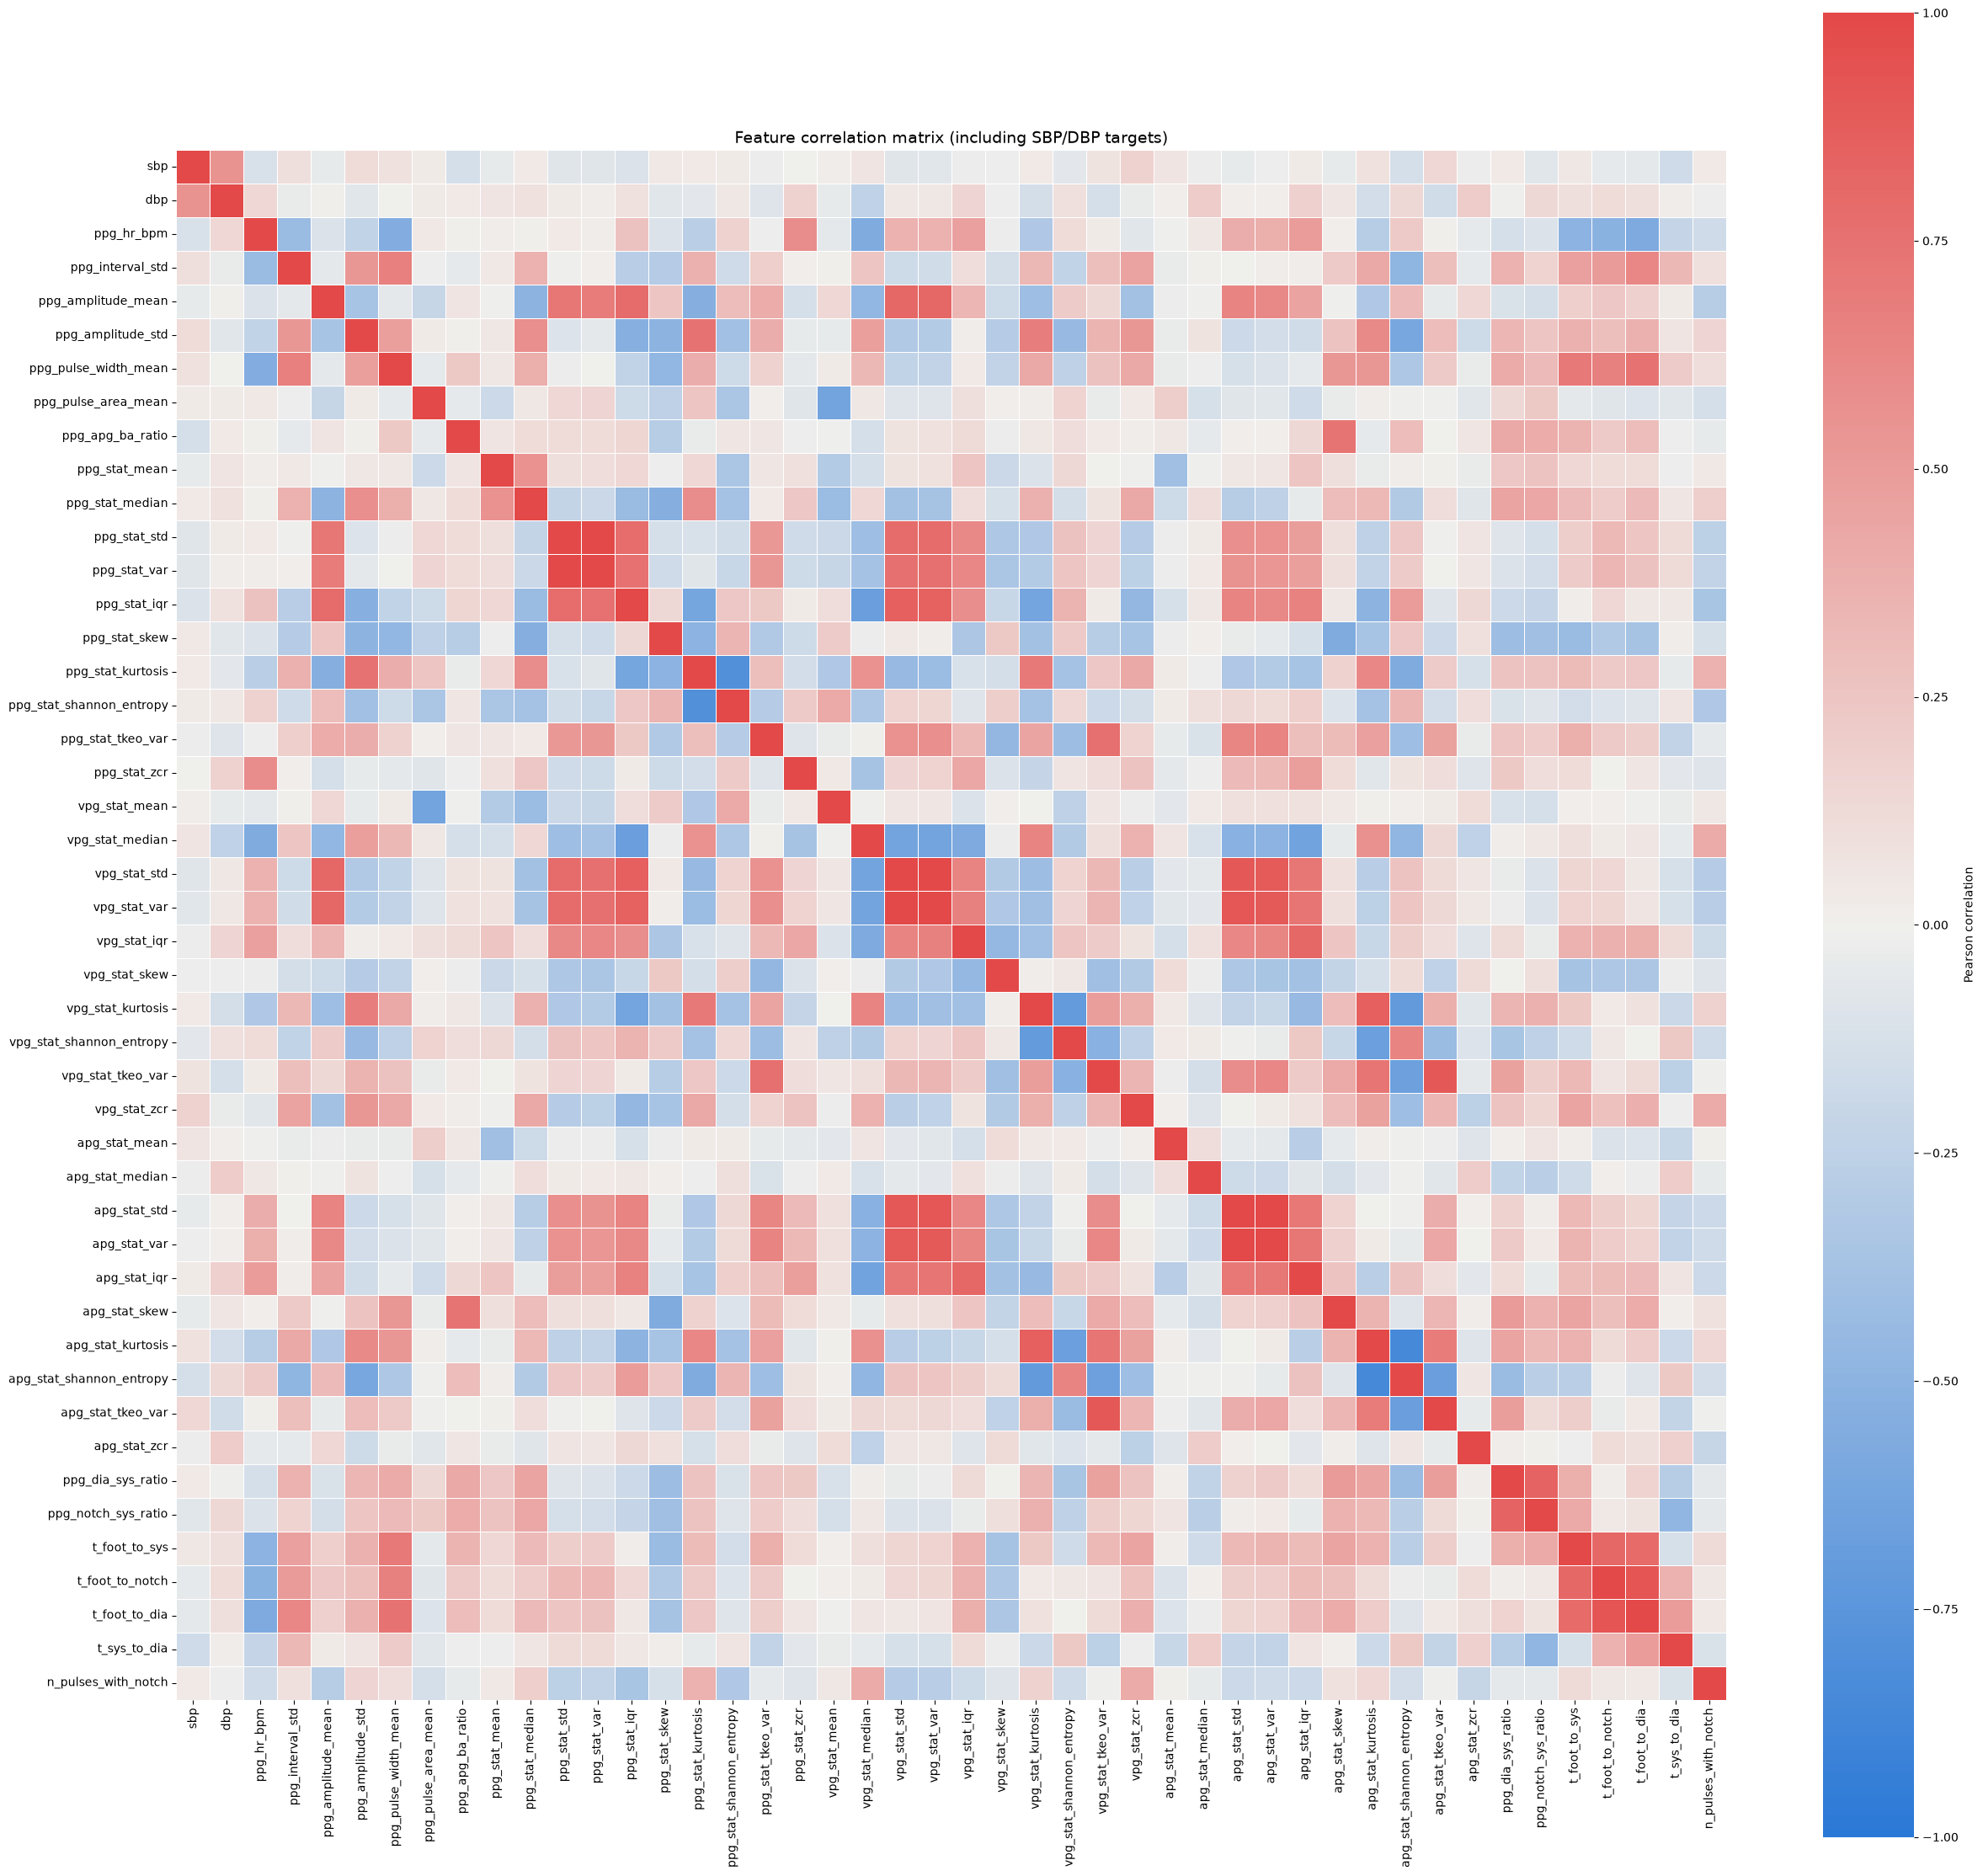

In [83]:
from matplotlib.colors import LinearSegmentedColormap

# blue <-> gray <-> red, blue = negative correlation, red = positive correlation
diverging_cmap = LinearSegmentedColormap.from_list(
    'bp_diverging', ['#2a78d6', '#f0efec', '#e34948']
)

corr = features_df.corr()
n_cols = len(corr)
show_annot = n_cols <= 15  # per-cell numbers only stay legible on a small matrix

plt.figure(figsize=(max(10, n_cols * 0.55), max(8, n_cols * 0.5)))
sns.heatmap(
    corr, cmap=diverging_cmap, vmin=-1, vmax=1, center=0,
    annot=show_annot, fmt='.2f', square=True, linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'},
)
plt.title('Feature correlation matrix (including SBP/DBP targets)', fontsize=14)
plt.tight_layout()
plt.show()


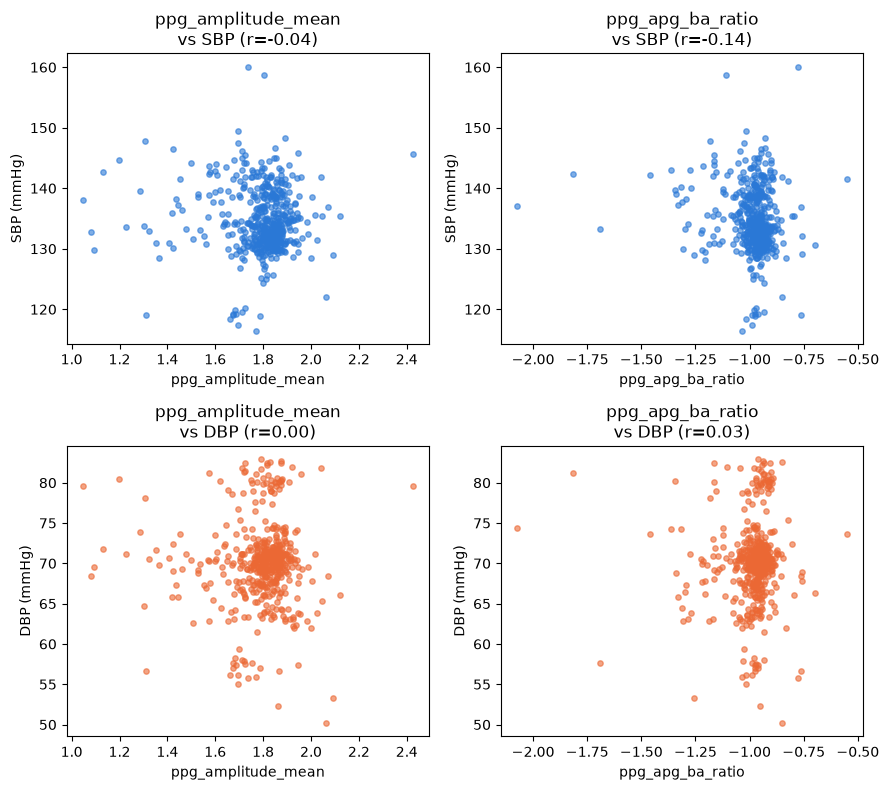

In [84]:
# SBP consistently in blue, DBP in orange across every panel below (fixed category order)
SBP_COLOR = '#2a78d6'
DBP_COLOR = '#eb6834'

candidate_features = ['ppg_amplitude_mean', 'ppg_apg_ba_ratio']

fig, axes = plt.subplots(2, len(candidate_features), figsize=(4.5 * len(candidate_features), 8))

for col, feat in enumerate(candidate_features):
    r_sbp = features_df[feat].corr(features_df['sbp'])
    axes[0, col].scatter(features_df[feat], features_df['sbp'], s=15, alpha=0.6, color=SBP_COLOR)
    axes[0, col].set_title(f'{feat}\nvs SBP (r={r_sbp:.2f})')
    axes[0, col].set_xlabel(feat)
    axes[0, col].set_ylabel('SBP (mmHg)')

    r_dbp = features_df[feat].corr(features_df['dbp'])
    axes[1, col].scatter(features_df[feat], features_df['dbp'], s=15, alpha=0.6, color=DBP_COLOR)
    axes[1, col].set_title(f'{feat}\nvs DBP (r={r_dbp:.2f})')
    axes[1, col].set_xlabel(feat)
    axes[1, col].set_ylabel('DBP (mmHg)')

plt.tight_layout()
plt.show()


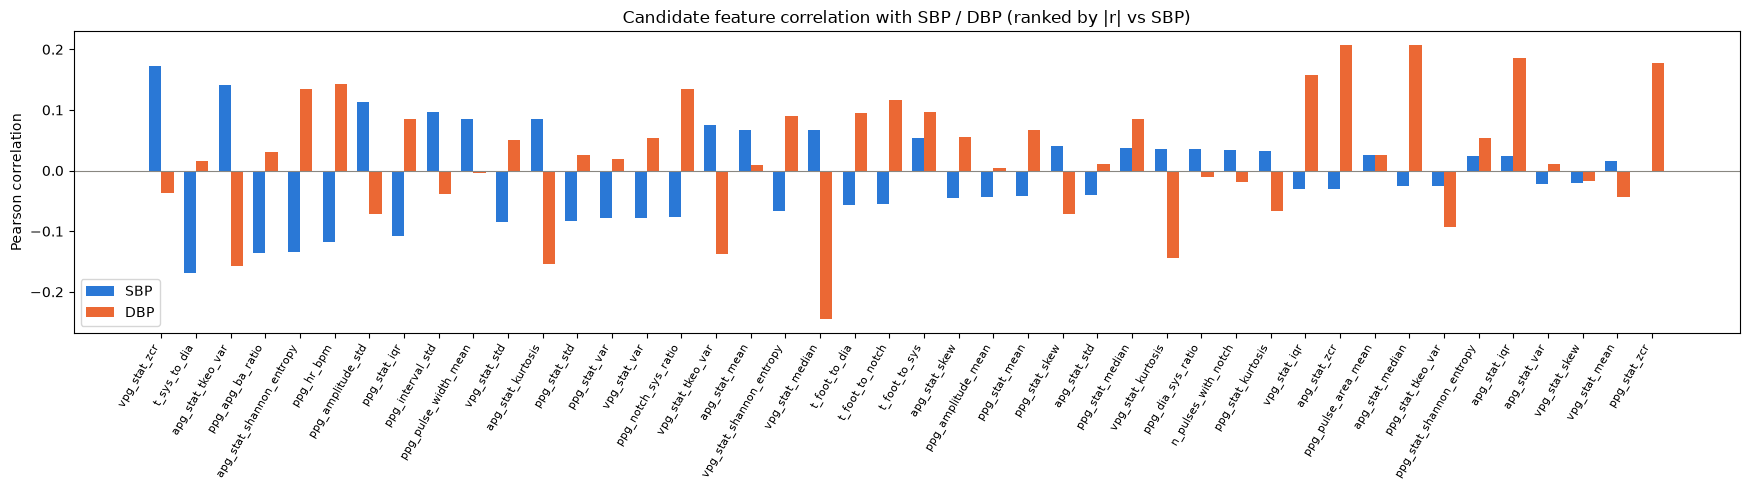

In [85]:
feature_cols = [c for c in features_df.columns if c not in ('sbp', 'dbp')]
corr_sbp = features_df[feature_cols].corrwith(features_df['sbp'])
corr_dbp = features_df[feature_cols].corrwith(features_df['dbp'])

order = corr_sbp.abs().sort_values(ascending=False).index  # rank by |correlation| with SBP
x = np.arange(len(order))
width = 0.35

fig, ax = plt.subplots(figsize=(max(12, len(order) * 0.4), 5))
ax.bar(x - width / 2, corr_sbp[order].values, width, label='SBP', color=SBP_COLOR)
ax.bar(x + width / 2, corr_dbp[order].values, width, label='DBP', color=DBP_COLOR)
ax.axhline(0, color='#898781', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Pearson correlation')
ax.set_title('Candidate feature correlation with SBP / DBP (ranked by |r| vs SBP)')
ax.legend()
plt.tight_layout()
plt.show()


In [86]:
from scipy.signal import find_peaks


def extract_ptt_features(ppg_peaks, r_peaks, fs=125, max_ptt=0.6):
    """Pulse transit time (PTT): delay from each ECG R-peak to the next PPG systolic peak.
    Usually the strongest single feature for cuffless BP (shorter PTT = higher BP)."""
    ppg_peaks = np.asarray(ppg_peaks)
    r_peaks = np.asarray(r_peaks)

    ptt = []
    for r in r_peaks:
        nxt = ppg_peaks[(ppg_peaks > r) & (ppg_peaks < r + int(max_ptt * fs))]
        if len(nxt):
            ptt.append((nxt[0] - r) / fs)

    if not ptt:
        return {'ptt_mean': np.nan, 'ptt_median': np.nan, 'ptt_std': np.nan, 'ptt_n_beats': 0}
    return {
        'ptt_mean': np.mean(ptt),
        'ptt_median': np.median(ptt),
        'ptt_std': np.std(ptt),
        'ptt_n_beats': len(ptt),
    }


def extract_all_features(ppg_win, abp_win, ecg_win, fs=125):
    """Combined extractor for one 5-second window: PTT + PPG morphology + fiducial + window stats + labels.
    Returns a flat dict (one row of the feature table), or None if the PPG has too few beats."""
    ppg_signals, ppg_info = nk.ppg_process(ppg_win, sampling_rate=fs)
    ecg_signals, ecg_info = nk.ecg_process(ecg_win, sampling_rate=fs)

    # morphology features already need >= 2 beats; skip window otherwise
    feats = extract_ppg_features(ppg_signals, ppg_info, fs)
    if feats is None:
        return None

    # PTT (ECG R-peak -> PPG systolic peak) - the priority feature
    feats.update(extract_ptt_features(ppg_info['PPG_Peaks'], ecg_info['ECG_R_Peaks'], fs))
    feats['ecg_hr_bpm'] = ecg_signals['ECG_Rate'].mean()

    # fiducial landmarks (often None on this dataset, so merge only if found)
    fiducial = extract_ppg_fiducial_features(ppg_signals, ppg_info, fs)
    if fiducial is not None:
        feats.update(fiducial)

    # non-fiducial statistics over PPG, VPG, APG
    clean = ppg_signals['PPG_Clean'].values
    vpg = np.gradient(clean)
    apg = np.gradient(vpg)
    feats.update(extract_window_statistics(clean, fs, prefix='ppg_stat_'))
    feats.update(extract_window_statistics(vpg, fs, prefix='vpg_stat_'))
    feats.update(extract_window_statistics(apg, fs, prefix='apg_stat_'))

    # labels: median of detected ABP peaks/troughs is more robust than window max/min
    sys_idx, _ = find_peaks(abp_win, distance=int(0.4 * fs))
    dia_idx, _ = find_peaks(-abp_win, distance=int(0.4 * fs))
    if len(sys_idx) == 0 or len(dia_idx) == 0:
        return None
    feats['sbp'] = np.median(abp_win[sys_idx])
    feats['dbp'] = np.median(abp_win[dia_idx])
    return feats

In [87]:
n_windows_to_use = 500  # subset for now

rows = []
for i in range(n_windows_to_use):
    try:
        feats = extract_all_features(ppg[i], bp[i], ecg[i], sample_size)
    except Exception:
        continue  # neurokit can fail on noisy windows
    if feats is not None:
        feats['window'] = i
        rows.append(feats)

all_features_df = pd.DataFrame(rows).set_index('window')
print(f"Extracted features for {len(all_features_df)}/{n_windows_to_use} windows")
print(f"Windows with PTT: {(all_features_df['ptt_n_beats'] > 0).sum()}")
print(f"PTT vs SBP r = {all_features_df['ptt_mean'].corr(all_features_df['sbp']):.2f}, "
      f"vs DBP r = {all_features_df['ptt_mean'].corr(all_features_df['dbp']):.2f}")
all_features_df.head()

Extracted features for 500/500 windows
Windows with PTT: 500
PTT vs SBP r = 0.13, vs DBP r = 0.09


,ppg_hr_bpm,ppg_interval_std,ppg_amplitude_mean,ppg_amplitude_std,ppg_pulse_width_mean,ppg_pulse_area_mean,ppg_apg_ba_ratio,ptt_mean,ptt_median,ptt_std,...,apg_stat_zcr,sbp,dbp,ppg_dia_sys_ratio,ppg_notch_sys_ratio,t_foot_to_sys,t_foot_to_notch,t_foot_to_dia,t_sys_to_dia,n_pulses_with_notch
window,,,,,,,,,,,,,,,,,,,,,
0,122.061483,0.005479,1.789199,0.104733,0.172444,-0.018487,-0.947285,0.071111,0.072,0.006999,...,11.2,121.841618,67.185065,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,124.481328,0.003464,1.798773,0.082789,0.175000,-0.012850,-0.946810,0.080000,0.080,0.000000,...,9.4,124.747842,68.967875,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,123.456790,0.003464,1.808343,0.120660,0.175000,-0.004666,-0.950382,0.079111,0.080,0.004532,...,6.8,125.846835,69.773803,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,123.175182,0.005896,1.798631,0.130368,0.172444,-0.018154,-0.933006,0.072800,0.072,0.007547,...,9.4,122.671968,67.111799,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,124.223602,0.006856,1.851906,0.075868,0.177000,-0.016192,-0.967340,0.080000,0.080,0.006532,...,10.2,125.578192,69.212096,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Largest gaps between DBP (median) and the raw window minimum:


,sbp,dbp,raw_max_mmHg,raw_min_mmHg,max_minus_sbp,dbp_minus_min
window,,,,,,
46,142.58,77.83,160.11,55.73,17.54,22.10
217,128.29,75.88,149.41,55.10,21.13,20.78
212,125.97,73.14,129.00,53.34,3.03,19.81


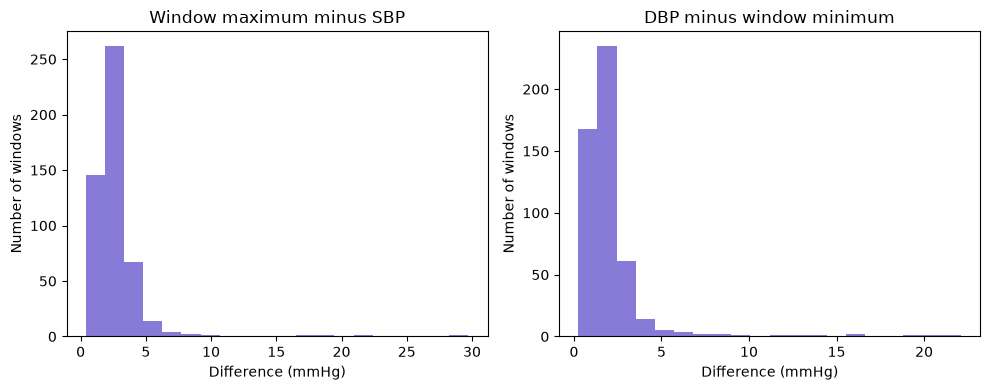

In [88]:
# Compare beat medians with the single highest/lowest sample
# One unusual sample affects an extreme more than a median.
window_abp = bp[all_features_df.index]
target_check = all_features_df[['sbp', 'dbp']].copy()
target_check['raw_max_mmHg'] = window_abp.max(axis=1)
target_check['raw_min_mmHg'] = window_abp.min(axis=1)
target_check['max_minus_sbp'] = target_check.raw_max_mmHg - target_check.sbp
target_check['dbp_minus_min'] = target_check.dbp - target_check.raw_min_mmHg

print("Largest gaps between DBP (median) and the raw window minimum:")
display(target_check.nlargest(3, 'dbp_minus_min').round(2))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, difference, title in zip(axes,
        [target_check.max_minus_sbp, target_check.dbp_minus_min],
        ["Window maximum minus SBP", "DBP minus window minimum"]):
    ax.hist(difference.dropna(), bins=20, color="slateblue", alpha=.8)
    ax.set(xlabel="Difference (mmHg)", ylabel="Number of windows", title=title)
fig.tight_layout()
plt.show()

Instead of stopping at a number, return to the original signal. Select the window where draft DBP is furthest above the raw minimum. The dashed line is the median of the contributing troughs; the cross marks the single lowest reading.

This is a deliberately selected extreme example, not a typical window. Look for whether the low reading is isolated, whether neighboring beats also change, and whether the detector markers still make sense.

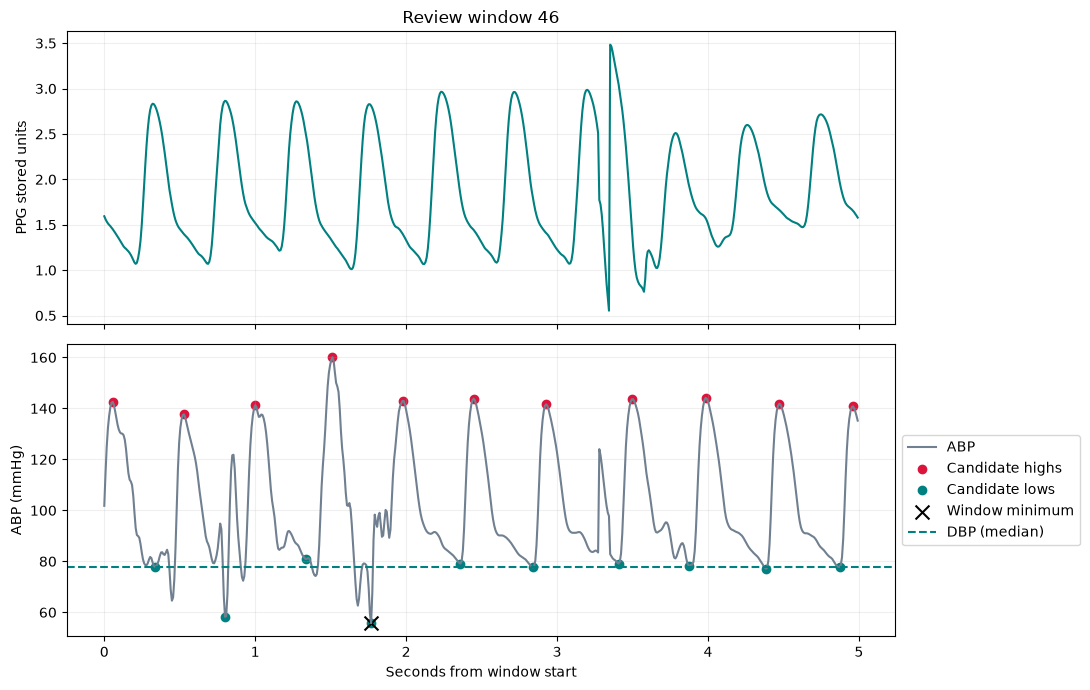

,sbp,dbp,raw_max_mmHg,raw_min_mmHg,max_minus_sbp,dbp_minus_min
window,,,,,,
46,142.58,77.83,160.11,55.73,17.54,22.1


In [89]:
review_id = int(target_check.dbp_minus_min.idxmax())
review_dbp = all_features_df.loc[review_id, 'dbp']
review_highs, _ = find_peaks(bp[review_id], distance=round(0.40 * sample_size))
review_lows, _ = find_peaks(-bp[review_id], distance=round(0.40 * sample_size))
minimum_index = int(np.argmin(bp[review_id]))
t = np.arange(window_size) / sample_size

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(t, ppg[review_id], color='teal')
axes[0].set(ylabel='PPG stored units', title=f'Review window {review_id}')
axes[1].plot(t, bp[review_id], color='slategray', label='ABP')
axes[1].scatter(review_highs / sample_size, bp[review_id][review_highs], color='crimson', label='Candidate highs')
axes[1].scatter(review_lows / sample_size, bp[review_id][review_lows], color='teal', label='Candidate lows')
axes[1].scatter(minimum_index / sample_size, bp[review_id][minimum_index], marker='x', s=100, color='black', label='Window minimum')
axes[1].axhline(review_dbp, linestyle='--', color='teal', label='DBP (median)')
axes[1].set(xlabel='Seconds from window start', ylabel='ABP (mmHg)')
axes[1].legend(loc='center left', bbox_to_anchor=(1, .5))
for ax in axes: ax.grid(alpha=.2)
plt.tight_layout(); plt.show()
display(target_check.loc[[review_id]].round(2))

Plot pulse rate and filtered PPG variation against draft SBP and DBP. Each dot is one five-second window from recording 0. Color indicates time so we can see whether groups of points come from the same part of the recording.

An upward pattern would mean the two measurements tend to rise together in these windows. It does not establish that one causes the other, or that a model would predict pressure well in another recording. The targets are still draft values.

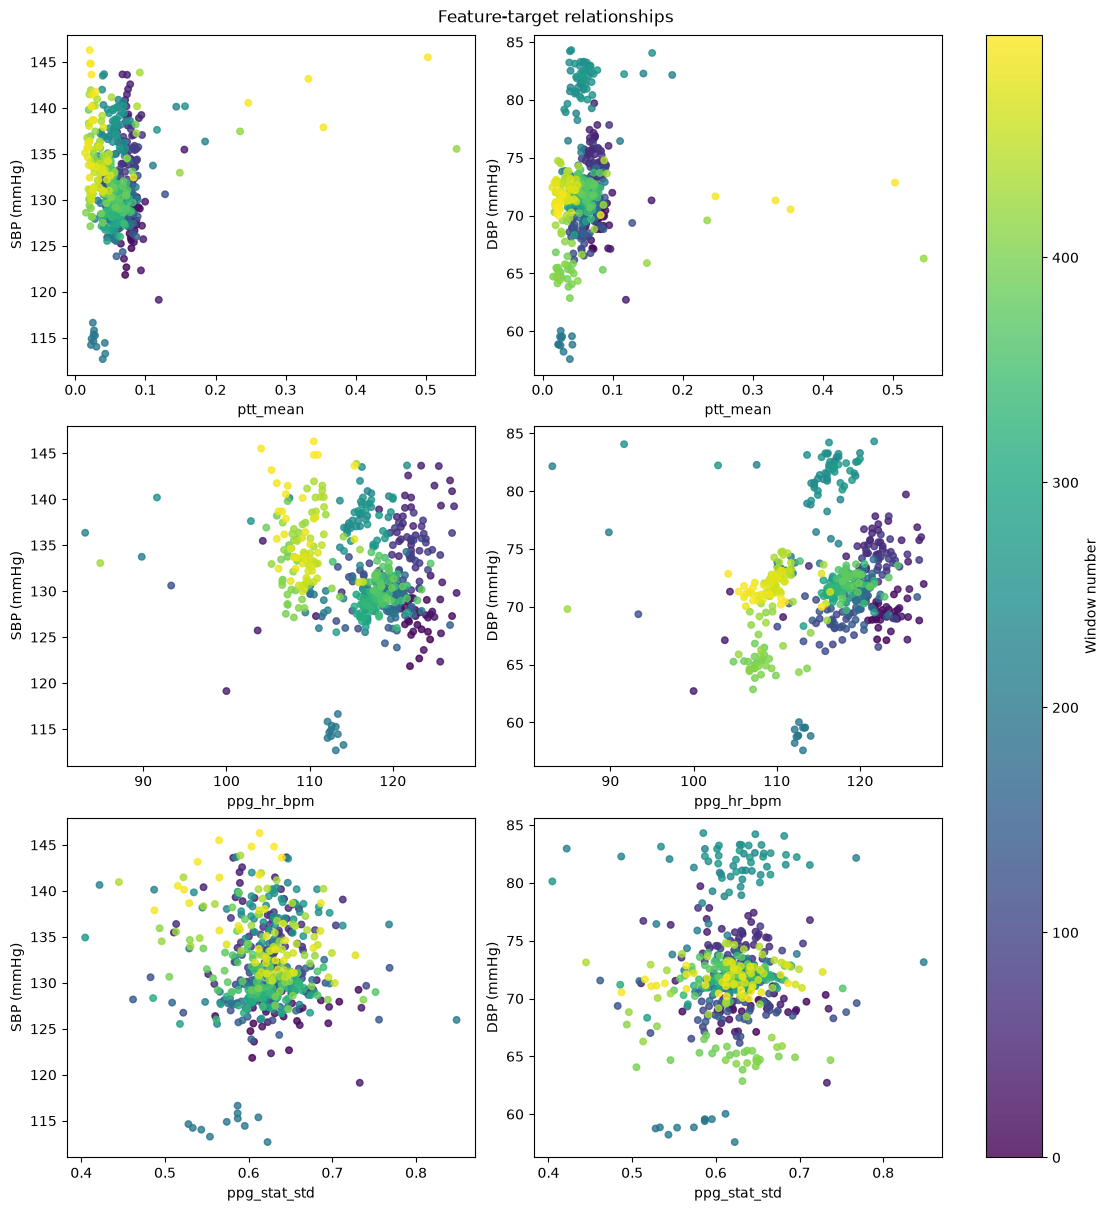

,sbp,dbp
ptt_mean,-0.073,0.184
ppg_hr_bpm,-0.185,0.186
ppg_stat_std,-0.016,0.065


In [92]:
input_features = ['ptt_mean', 'ppg_hr_bpm', 'ppg_stat_std']
target_features = ['sbp', 'dbp']
fig, axes = plt.subplots(len(input_features), 2, figsize=(11, 4 * len(input_features)), layout='constrained')
for row, feature in enumerate(input_features):
    for col, target in enumerate(target_features):
        dots = axes[row, col].scatter(all_features_df[feature], all_features_df[target],
                                      c=all_features_df.index, cmap='viridis', s=22, alpha=.8)
        axes[row, col].set(xlabel=feature, ylabel='SBP (mmHg)' if col == 0 else 'DBP (mmHg)')
fig.colorbar(dots, ax=axes.ravel().tolist(), label='Window number')
fig.suptitle('Feature-target relationships')
plt.show()

relationships = all_features_df[input_features + target_features].corr(method='spearman').loc[input_features, target_features]
display(relationships.round(3))

Nearby windows share the same recording and may move together over time. Compare the relationship in their levels with the relationship in their changes: subtract the previous window's value from the current one.

For example, a pulse-rate change of +2 means the estimate increased by 2 BPM since the preceding window. We keep only truly adjacent windows, so a missing window cannot create a false consecutive pair. Spearman correlation summarizes whether larger values tend to go with larger values; it ranges from −1 to +1. A value near zero means little monotonic association, not proof of no possible relationship.

This is another descriptive view, not a statistical independence test or a model evaluation. Differencing does not remove every time-series dependency.

In [ ]:
window_recording = np.repeat(np.arange(len(lengths)), lengths // window_size)

ordered = all_features_df.sort_index()
values = ordered[input_features + target_features]
rec_ids = pd.Series(window_recording[ordered.index], index=ordered.index)
adjacent = ordered.index.to_series().diff().eq(1) & rec_ids.eq(rec_ids.shift())
changes = values.diff().loc[adjacent]
change_correlations = changes.corr(method='spearman').loc[input_features, target_features]

comparison_rows = []
for feature in input_features:
    for target in target_features:
        comparison_rows.append({
            'PPG_feature': feature, 'target': target,
            'window_level_correlation': relationships.loc[feature, target],
            'adjacent_change_correlation': change_correlations.loc[feature, target],
            'complete_window_pairs': len(values[[feature, target]].dropna()),
            'complete_change_pairs': len(changes[[feature, target]].dropna()),
        })
relationship_comparison = pd.DataFrame(comparison_rows)
display(relationship_comparison.round(3))

,PPG_feature,target,window_level_correlation,adjacent_change_correlation,complete_window_pairs,complete_change_pairs
0,ptt_mean,sbp,-0.073,-0.031,500,494
1,ptt_mean,dbp,0.184,0.114,500,494
2,ppg_hr_bpm,sbp,-0.185,0.123,500,494
3,ppg_hr_bpm,dbp,0.186,0.187,500,494
4,ppg_stat_std,sbp,-0.016,0.134,500,494
5,ppg_stat_std,dbp,0.065,0.185,500,494
